In [1]:
import sys
import os
sys.path.append('../')
import seaborn as sns

import skimage
import microdet.mnds
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Analysis of number of objects in each training subset

In [2]:
directory = '/scr/yren/micronuclei-detection/microdet/all_data_micronuclei_no_rescale/train'
scale_factor = 1.0
files = os.listdir(directory)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('.phenotype_outlines.png')]
annot_files.sort()

training_files = annot_files.copy()

In [3]:
df = pd.read_csv('/scr/yren/micronuclei-detection/microdet/all_data_micronuclei_no_rescale/metadata.csv')
df_train = df[df.split == 'train']
df_train

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.50,train
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.50,train
6,20X_c0-DAPI_A1_Tile-190.phenotype.tif,pilot,14,4.25,train
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif,screen,14,4.25,train
11,20X_c0-DAPI_A1_Tile-90.phenotype.tif,pilot,14,4.25,train
...,...,...,...,...,...
220,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,BBBC039,20,13.10,train
224,IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2...,BBBC039,20,13.10,train
226,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,20,13.10,train
227,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,20,13.10,train


In [4]:
objects = pd.DataFrame([{'screen_pilot': 0, 'hela_rpe1': 0, 'BBBC039': 0, 'mnfinder_train': 0}])

for i in training_files:
    gt = skimage.io.imread(directory + '/' + i)
    num_obj = len(np.unique(skimage.measure.label(gt))) - 1 # minus background
    name = i.replace('.phenotype_outlines.png', '.phenotype.tif')
    subset = df_train.loc[df_train.filenames == name, 'datasets'].iloc[0]
    # print(subset)
    
    if (subset == 'screen') or (subset == 'pilot'):
        current_num_obj = objects['screen_pilot'].iloc[0]
        objects['screen_pilot'] = current_num_obj + num_obj
    elif (subset == 'HeLa') or (subset == 'RPE1'):
        current_num_obj = objects['hela_rpe1'].iloc[0]
        objects['hela_rpe1'] = current_num_obj + num_obj
    else:
        current_num_obj = objects[subset].iloc[0]
        objects[subset] = current_num_obj + num_obj
        

Text(0.5, 1.0, 'Screen 87')

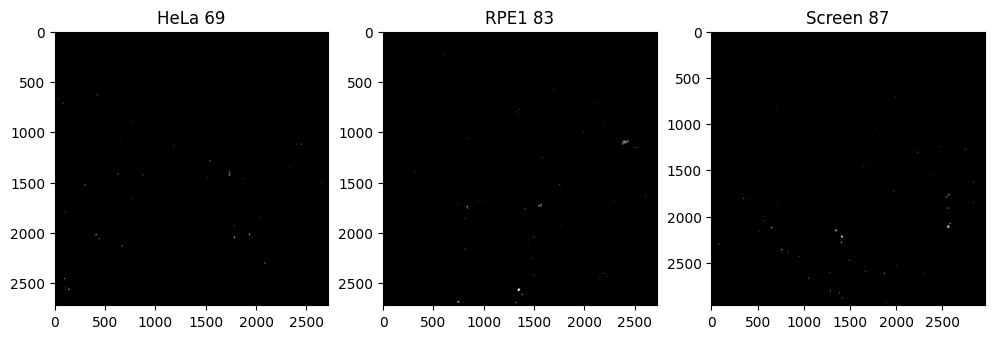

In [5]:
path1 = directory + '/C1-20X_c0_B3_Tile-5.phenotype_outlines.png'
path2 = directory + '/C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png'
path3 = directory + '/C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype_outlines.png'

gt1 = skimage.io.imread(path1)
gt2 = skimage.io.imread(path2)
gt3 = skimage.io.imread(path3)

fig, ax = plt.subplots(1,3, figsize=(12,12))
ax[0].imshow(gt1, cmap='gray')
ax[0].set_title(f'HeLa {len(np.unique(skimage.measure.label(gt1))) - 1}')

ax[1].imshow(gt2, cmap='gray')
ax[1].set_title(f'RPE1 {len(np.unique(skimage.measure.label(gt2))) - 1}')

ax[2].imshow(gt3, cmap='gray')
ax[2].set_title(f'Screen {len(np.unique(skimage.measure.label(gt3))) - 1}')

In [43]:
objects

,screen_pilot,hela_rpe1,BBBC039,mnfinder_train
0,1024,152,799,1749


Text(0.5, 1.0, 'Number of objects')

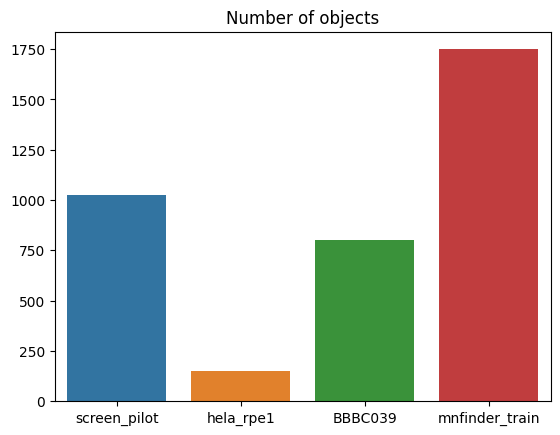

In [ ]:
import seaborn as sns
sns.barplot(objects)
plt.title('Number of objects in each dataset')

# Before oversampling

In [15]:
images = {}
for fname in tqdm(training_files):
    imid = fname.split('.')[0]
    im = microdet.mnds.read_image(directory, imid, 'phenotype.tif', scale_factor)
    im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
    #im = skimage.exposure.rescale_intensity(im, out_range=np.float32)
    mni = microdet.mnds.read_micronuclei_annotations(directory, imid)
    mnm = microdet.mnds.read_image(directory, imid, 'phenotype_outlines.png', scale_factor)
    nuc = microdet.mnds.read_nuclei_masks(directory, imid)
    # all_locs.append(mni)
    images[imid] = {"image":im, "micro":mnm, "nuclei":nuc, "loc":mni}

100%|██████████| 121/121 [00:52<00:00,  2.29it/s]


In [20]:
index = []

In [21]:
def randomize_patch_index(): # This function is only applied to training set
    #print("Randomized",self.shuffled,"times"
    PS = 256
    
    
    for imid in images:
        # Generate random patch coordinates C
        H, W = images[imid]["image"].shape
        patches_per_image = (W // PS) * (H // PS)
        
        # print(f'{imid}: height - {H}, width - {W}, patches - {patches_per_image}')
        X = np.random.randint(0, W - PS, patches_per_image)
        Y = np.random.randint(0, H - PS, patches_per_image)
        C = np.stack((Y,X)).T
        A = {}

        # Micronuclei locations
        for k,r in images[imid]["loc"].iterrows():
            # Check whether the location r.x,r.y is covered by patches
            matches = np.where(np.logical_and( 
                        np.logical_and(C[:,0] < r.y, C[:,0] + PS > r.y),
                        np.logical_and(C[:,1] < r.x, C[:,1] + PS > r.x)
            ))
            matches = matches[0]
            if len(matches) > 0:
                # Annotate all patches that cover the location
                for m in matches:
                    try: A[m].append((r.y, r.x))
                    except: A[m] = [(r.y, r.x)]
            elif (r.y + PS < H or r.x + PS < W): # or statement might fit non-square images?
                # If not covered, add a new patch that covers the location
                if (r.y == 0 and r.x == 0):
                    extra = [[0, 0]]
                elif (r.y != 0 and r.x == 0):
                    if (r.y + PS > H):
                        extra = [[H - PS, 0]]
                    else:
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), 0]]
                elif (r.y == 0 and r.x != 0):
                    if (r.x + PS > W):
                        extra = [[0, W - PS]]
                    else:
                        extra = [[0, np.random.randint(max(r.x - PS,0), r.x)]]
                else:
                    if (r.y + PS < H and r.x + PS < W):
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), np.random.randint(max(r.x - PS,0), r.x)]]
                    elif (r.y + PS < H and r.x + PS > W):
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), W - PS]]
                    elif (r.y + PS > H and r.x + PS < W):
                        extra = [[H - PS, np.random.randint(max(r.x - PS,0), r.x)]]
                    elif (r.y + PS > H and r.x + PS > W):
                        extra = [[H - PS, W - PS]]
                C = np.append(C, extra, axis=0)
                A[C.shape[0]-1] = [(r.y, r.x)]

        # Put annotated patches in the index
        count = 0
        for k in A:
            index.append({"Image":imid, "coord": C[k,:].tolist(), "locs":A[k]})
            count += 1

        # Complete budget with non-annotated patches
        U = [x for x in range(patches_per_image) if x not in A]
        pointer = 0
        while count < patches_per_image:
            k = U[pointer]
            index.append({"Image":imid, "coord": C[k,:].tolist(), "locs":[]})
            pointer += 1
            count += 1
            



In [22]:
randomize_patch_index()

In [24]:
print(len(index))

2588


## Count number of objects for each subset in training crops

In [45]:
objects = pd.DataFrame([{'screen_pilot': 0, 'hela_rpe1': 0, 'BBBC039': 0, 'mnfinder_train': 0}])
df = pd.read_csv('/scr/yren/all_data_micronuclei_no_rescale/metadata.csv')

In [49]:
PS = 256
for item in index:
    # print(item)
    imid = item['Image']
    r,c = int(item["coord"][0]), int(item["coord"][1])
    mn_mask = images[item["Image"]]["micro"][r:r+PS,c:c+PS]
    
    # locate subset
    subset = df.loc[df.filenames == imid + '.phenotype.tif', 'datasets'].iloc[0]
    num_of_obj = len(np.unique(skimage.measure.label(mn_mask))) - 1 # minus background label
    
    if (subset == 'screen') or (subset == 'pilot'):
        current_num_obj = objects['screen_pilot'].iloc[0]
        objects['screen_pilot'] = current_num_obj + num_obj
    elif (subset == 'HeLa') or (subset == 'RPE1'):
        current_num_obj = objects['hela_rpe1'].iloc[0]
        objects['hela_rpe1'] = current_num_obj + num_obj
    else:
        current_num_obj = objects[subset].iloc[0]
        objects[subset] = current_num_obj + num_obj

In [50]:
objects

,screen_pilot,hela_rpe1,BBBC039,mnfinder_train
0,17424,2400,5352,5880


Text(0.5, 1.0, 'Number of objects in training crops')

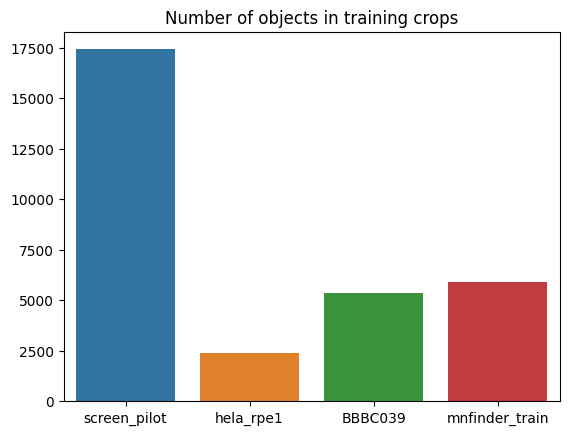

In [51]:
sns.barplot(objects)
plt.title('Number of objects in training crops')

# Modified oversampling strategy

In [25]:
df = pd.read_csv(directory.replace('train', 'metadata.csv'))

In [39]:
df.loc[df.filenames == imid + '.phenotype.tif', 'datasets'].iloc[0]

'BBBC039'

In [40]:
np.unique(df.datasets.to_list())

array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype='<U19')

In [26]:
index_oversampled = []

In [42]:
len(images)

121

<Axes: >

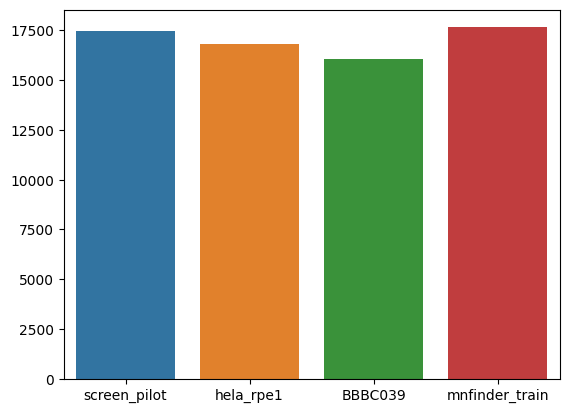

In [55]:
d = pd.DataFrame([{'screen_pilot':17424, 'hela_rpe1':2400*7, 'BBBC039':5352*3, 'mnfinder_train':5880*3}])
sns.barplot(d)

In [70]:
def randomize_patch_index_oversampled(): # This function is only applied to training set
    #print("Randomized",self.shuffled,"times"
    PS = 256
    
    
    for imid in images:
        # Generate random patch coordinates C
        H, W = images[imid]["image"].shape
        patches_per_image = (W // PS) * (H // PS)
        
        # oversample images that have less micronuclei
        subset = df.loc[df.filenames == imid + '.phenotype.tif', 'datasets'].iloc[0]
        if subset in ['HeLa', 'RPE1']:
            patches_per_image = patches_per_image * 7
        elif subset in ['BBBC039', 'mnfinder_train']:
            patches_per_image = patches_per_image * 5
        # if H < 1500 or W < 1500:
        #     patches_per_image = patches_per_image * 100
            
        # print(f'{imid}: height - {H}, width - {W}, patches - {patches_per_image}')
        X = np.random.randint(0, W - PS, patches_per_image)
        Y = np.random.randint(0, H - PS, patches_per_image)
        C = np.stack((Y,X)).T
        A = {}

        # Micronuclei locations
        for k,r in images[imid]["loc"].iterrows():
            # Check whether the location r.x,r.y is covered by patches
            matches = np.where(np.logical_and( 
                        np.logical_and(C[:,0] < r.y, C[:,0] + PS > r.y),
                        np.logical_and(C[:,1] < r.x, C[:,1] + PS > r.x)
            ))
            matches = matches[0]
            if len(matches) > 0:
                # Annotate all patches that cover the location
                for m in matches:
                    try: A[m].append((r.y, r.x))
                    except: A[m] = [(r.y, r.x)]
            elif (r.y + PS < H or r.x + PS < W): # or statement might fit non-square images?
                # If not covered, add a new patch that covers the location
                if (r.y == 0 and r.x == 0):
                    extra = [[0, 0]]
                elif (r.y != 0 and r.x == 0):
                    if (r.y + PS > H):
                        extra = [[H - PS, 0]]
                    else:
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), 0]]
                elif (r.y == 0 and r.x != 0):
                    if (r.x + PS > W):
                        extra = [[0, W - PS]]
                    else:
                        extra = [[0, np.random.randint(max(r.x - PS,0), r.x)]]
                else:
                    if (r.y + PS < H and r.x + PS < W):
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), np.random.randint(max(r.x - PS,0), r.x)]]
                    elif (r.y + PS < H and r.x + PS > W):
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), W - PS]]
                    elif (r.y + PS > H and r.x + PS < W):
                        extra = [[H - PS, np.random.randint(max(r.x - PS,0), r.x)]]
                    elif (r.y + PS > H and r.x + PS > W):
                        extra = [[H - PS, W - PS]]
                C = np.append(C, extra, axis=0)
                A[C.shape[0]-1] = [(r.y, r.x)]

        # Put annotated patches in the index
        count = 0
        for k in A:
            index_oversampled.append({"Image":imid, "coord": C[k,:].tolist(), "locs":A[k]})
            count += 1

        # Complete budget with non-annotated patches
        U = [x for x in range(patches_per_image) if x not in A]
        pointer = 0
        while count < patches_per_image:
            k = U[pointer]
            index_oversampled.append({"Image":imid, "coord": C[k,:].tolist(), "locs":[]})
            pointer += 1
            count += 1

In [71]:
randomize_patch_index_oversampled()

In [72]:
print(len(index_oversampled))

16366


In [73]:
objects_oversampled = pd.DataFrame([{'screen_pilot': 0, 'hela_rpe1': 0, 'BBBC039': 0, 'mnfinder_train': 0}])

## Count number of objects for each subset in oversampled training crops

In [74]:
PS = 256
for item in index_oversampled:
    # print(item)
    imid = item['Image']
    r,c = int(item["coord"][0]), int(item["coord"][1])
    mn_mask = images[item["Image"]]["micro"][r:r+PS,c:c+PS]
    
    # locate subset
    subset = df.loc[df.filenames == imid + '.phenotype.tif', 'datasets'].iloc[0]
    num_of_obj = len(np.unique(skimage.measure.label(mn_mask))) - 1 # minus background label
    
    if (subset == 'screen') or (subset == 'pilot'):
        current_num_obj = objects_oversampled['screen_pilot'].iloc[0]
        objects_oversampled['screen_pilot'] = current_num_obj + num_obj
    elif (subset == 'HeLa') or (subset == 'RPE1'):
        current_num_obj = objects_oversampled['hela_rpe1'].iloc[0]
        objects_oversampled['hela_rpe1'] = current_num_obj + num_obj
    else:
        current_num_obj = objects_oversampled[subset].iloc[0]
        objects_oversampled[subset] = current_num_obj + num_obj

Text(0.5, 1.0, 'Number of objects in oversampled training crops')

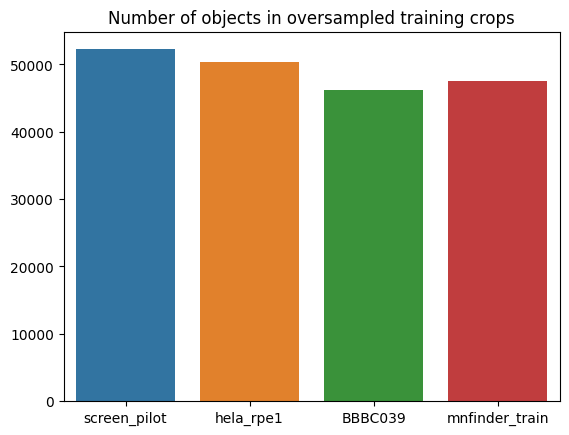

In [75]:
sns.barplot(objects_oversampled)
plt.title('Number of objects in oversampled training crops')